# 03 — Feature Engineering y Entrenamiento del Modelo
## Oráculo del Balón — Predicción Mundial 2026

**Objetivo:** Construir todas las features necesarias, ensamblar el dataset 
de entrenamiento y entrenar los modelos de clasificación.

### Secciones:
- 3.1 Cálculo de ELO Rating (desde 1872)
- 3.2 Construcción de features por partido
- 3.3 Dataset final para el modelo
- 3.4 Entrenamiento XGBoost y Regresión Logística
- 3.5 Validación con WC2022
- 3.6 Métricas Log-Loss y Brier Score

## 3.1 Cálculo de ELO Rating

Calculamos el ELO acumulativo desde 1872 usando todos los partidos históricos.

**¿Por qué desde 1872?**
Si empezamos en 1993, todos los equipos arrancan con ELO=1500 sin diferencia.
Desde 1872, Brasil acumula ~150 años de victorias → ELO≈2100.
San Marino, con pocas victorias → ELO≈1200.

**Fórmula:**
- prob_esperada = 1 / (1 + 10^((R_rival - R_propio) / 400))
- R_nuevo = R_actual + K × (resultado - prob_esperada)
- K varía: World Cup=60, Clasificatorias=40, Amistosos=20

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# ── Rutas del proyecto ──────────────────────────────────────────
BASE_DIR      = Path('..') 
DATA_RAW      = BASE_DIR / 'data' / 'raw'
DATA_PROC     = BASE_DIR / 'data' / 'processed'

# ── Constantes Time Decay (consistentes con notebook 02) ────────
FECHA_CORTE = pd.Timestamp('2026-06-10')
HALF_LIFE   = 3 * 365   # 3 años en días

print("✅ Imports OK")
print(f"   DATA_PROC → {DATA_PROC.resolve()}")

✅ Imports OK
   DATA_PROC → /Users/jpurquilla/Desktop/UES-ML/oraculo-mundial2026/data/processed


In [2]:
# Cargamos el histórico completo para calcular ELO acumulativo
df_hist = pd.read_csv(DATA_PROC / 'results_historico_1872.csv', parse_dates=['date'])

print(f"Shape: {df_hist.shape}")
print(f"Rango de fechas: {df_hist['date'].min().date()} → {df_hist['date'].max().date()}")
print(f"\nColumnas: {df_hist.columns.tolist()}")
print(f"\nPrimeras filas:")
df_hist.head(3)

Shape: (49257, 9)
Rango de fechas: 1872-11-30 → 2026-03-31

Columnas: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']

Primeras filas:


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False


### Factor K — Importancia del partido

El factor K controla qué tan rápido cambia el ELO según el tipo de torneo.

| Torneo                    | K  | Razón                              |
|---------------------------|----|------------------------------------|
| FIFA World Cup            | 60 | El torneo más importante           |
| Confederations Cup / Copa | 50 | Torneos oficiales de alta jerarquía|
| Qualifier / Clasificatoria| 40 | Partidos oficiales                 |
| Friendly / Amistoso       | 20 | Menor importancia                  |

Un K alto = el ELO cambia mucho con ese resultado.
Un K bajo = el ELO cambia poco (partidos que "no cuentan tanto").

In [3]:
def get_k_factor(tournament: str) -> int:
    """
    Retorna el factor K según el tipo de torneo.
    IMPORTANTE: verificar strings más específicos primero.
    """
    t = str(tournament).lower()
    
    # ── Primero: clasificatorias (más específico que 'world cup') ──
    if any(x in t for x in ['qualification', 'qualifier']):
        return 40
    
    # ── Luego: torneos principales ─────────────────────────────────
    elif 'fifa world cup' in t:
        return 60
    
    elif any(x in t for x in ['confederation', 'copa america',
                               'euro', 'africa cup', 'asian cup',
                               'gold cup', 'nations league']):
        return 50
    
    else:
        return 20

# ── Test ───────────────────────────────────────────────────────────
tests = [
    ('FIFA World Cup',               60),
    ('FIFA World Cup qualification', 40),
    ('Friendly',                     20),
    ('Copa America',                 50),
]
for torneo, k_esperado in tests:
    k = get_k_factor(torneo)
    estado = "✅" if k == k_esperado else "❌"
    print(f"{estado} '{torneo}' → K={k} (esperado {k_esperado})")

✅ 'FIFA World Cup' → K=60 (esperado 60)
✅ 'FIFA World Cup qualification' → K=40 (esperado 40)
✅ 'Friendly' → K=20 (esperado 20)
✅ 'Copa America' → K=50 (esperado 50)


### Función ELO — Paso a paso

Para cada partido entre Equipo A (local) y Equipo B (visitante):

1. **Calcular probabilidad esperada de A:**
   - diff = (ELO_B - ELO_A) / 400
   - prob_A = 1 / (1 + 10^diff)

2. **Definir resultado real:**
   - A gana → resultado_A = 1.0
   - Empate  → resultado_A = 0.5
   - A pierde → resultado_A = 0.0

3. **Actualizar ELO:**
   - ELO_A_nuevo = ELO_A + K × (resultado_A - prob_A)
   - ELO_B_nuevo = ELO_B + K × (resultado_B - prob_B)
   - Nota: resultado_B = 1 - resultado_A

**Ventaja de local:** Sumamos +100 al ELO del local antes de calcular 
la probabilidad (solo si el partido NO es en cancha neutral).
Esto refleja que jugar en casa tiene valor estadístico real.

In [4]:
def calcular_elo(df: pd.DataFrame,
                 elo_inicial: int = 1500,
                 home_advantage: int = 100) -> dict:
    """
    Calcula ELO acumulativo para todos los equipos.
    
    Parámetros:
    -----------
    df             : DataFrame con partidos ordenados por fecha
    elo_inicial    : ELO de partida para equipos sin historial
    home_advantage : Puntos extra para el local (si no es neutral)
    
    Retorna:
    --------
    dict {equipo: elo_actual}  → estado final del ELO
    También guarda snapshot histórico en lista 'historial'
    """
    
    # Diccionario con ELO actual de cada equipo
    elos = {}
    
    # Lista para guardar el ELO de CADA equipo ANTES de cada partido
    # Esto nos permite hacer un snapshot histórico (importante para WC2022)
    historial = []
    
    # Ordenar por fecha — imprescindible para que sea acumulativo
    df = df.sort_values('date').reset_index(drop=True)
    
    for _, row in df.iterrows():
        
        home = row['home_team']
        away = row['away_team']
        
        # Inicializar ELO si el equipo aparece por primera vez
        if home not in elos:
            elos[home] = elo_inicial
        if away not in elos:
            elos[away] = elo_inicial
        
        elo_h = elos[home]
        elo_a = elos[away]
        
        # ── Guardar snapshot ANTES del partido ──────────────────
        historial.append({
            'date'     : row['date'],
            'team'     : home,
            'elo_before': elo_h
        })
        historial.append({
            'date'     : row['date'],
            'team'     : away,
            'elo_before': elo_a
        })
        
        # ── Ventaja de local ────────────────────────────────────
        es_neutral = row.get('neutral', False)
        ajuste_local = 0 if es_neutral else home_advantage
        
        # ── Probabilidad esperada ───────────────────────────────
        diff = (elo_a - (elo_h + ajuste_local)) / 400
        prob_h = 1 / (1 + 10 ** diff)
        prob_a = 1 - prob_h
        
        # ── Resultado real ──────────────────────────────────────
        hs = row['home_score']
        as_ = row['away_score']
        
        if hs > as_:
            res_h, res_a = 1.0, 0.0   # Gana local
        elif hs < as_:
            res_h, res_a = 0.0, 1.0   # Gana visitante
        else:
            res_h, res_a = 0.5, 0.5   # Empate
        
        # ── Factor K ────────────────────────────────────────────
        K = get_k_factor(row['tournament'])
        
        # ── Actualizar ELO ──────────────────────────────────────
        elos[home] = elo_h + K * (res_h - prob_h)
        elos[away] = elo_a + K * (res_a - prob_a)
    
    return elos, historial

print("✅ Función calcular_elo() definida")

✅ Función calcular_elo() definida


In [5]:
print("⏳ Calculando ELO desde 1872... (puede tardar ~30 segundos)")

elos_finales, historial_elo = calcular_elo(df_hist)

print(f"✅ Cálculo completado")
print(f"   Equipos con ELO calculado: {len(elos_finales)}")
print(f"   Registros en historial: {len(historial_elo):,}")

⏳ Calculando ELO desde 1872... (puede tardar ~30 segundos)
✅ Cálculo completado
   Equipos con ELO calculado: 336
   Registros en historial: 98,514


In [6]:
# ── Top 10 equipos por ELO actual ───────────────────────────────
elo_series = pd.Series(elos_finales).sort_values(ascending=False)

print("🏆 Top 15 equipos por ELO Rating (junio 2026):")
print(elo_series.head(15).round(1).to_string())

print(f"\n📉 Bottom 5 equipos:")
print(elo_series.tail(5).round(1).to_string())

# ── Guardar ELO final ────────────────────────────────────────────
df_elo_final = elo_series.reset_index()
df_elo_final.columns = ['team', 'elo_rating']
df_elo_final.to_csv(DATA_PROC / 'elo_ratings.csv', index=False)
print(f"\n💾 Guardado: data/processed/elo_ratings.csv")

# ── Guardar historial completo ───────────────────────────────────
df_hist_elo = pd.DataFrame(historial_elo)
df_hist_elo.to_csv(DATA_PROC / 'elo_history.csv', index=False)
print(f"💾 Guardado: data/processed/elo_history.csv  ({df_hist_elo.shape})")

🏆 Top 15 equipos por ELO Rating (junio 2026):
Spain          2096.2
Argentina      2046.5
France         2022.1
Portugal       1957.1
Brazil         1952.0
England        1949.0
Ecuador        1926.3
Colombia       1922.8
Netherlands    1913.2
Germany        1899.9
Croatia        1897.5
Mexico         1895.7
Morocco        1895.2
Japan          1888.6
Uruguay        1884.0

📉 Bottom 5 equipos:
Brunei        1024.6
Bhutan        1021.7
Anguilla      1018.5
San Marino     972.2
Macau          968.9

💾 Guardado: data/processed/elo_ratings.csv
💾 Guardado: data/processed/elo_history.csv  ((98514, 3))


In [7]:
equipos_wc2026 = [
    'Algeria','Argentina','Australia','Austria','Belgium',
    'Bosnia and Herzegovina','Brazil','Canada','Cape Verde',
    'Colombia','Croatia','Curaçao','Czechia','DR Congo',
    'Ecuador','Egypt','England','France','Germany','Ghana',
    'Haiti','Iran','Iraq','Ivory Coast','Japan','Jordan',
    'Mexico','Morocco','Netherlands','New Zealand','Norway',
    'Panama','Paraguay','Portugal','Qatar','Saudi Arabia',
    'Scotland','Senegal','South Africa','South Korea','Spain',
    'Sweden','Switzerland','Tunisia','Turkey','USA',
    'Uruguay','Uzbekistan'
]

# Verificar cuáles tienen ELO calculado
con_elo    = [e for e in equipos_wc2026 if e in elos_finales]
sin_elo    = [e for e in equipos_wc2026 if e not in elos_finales]

print(f"✅ Equipos WC2026 con ELO: {len(con_elo)}/48")

if sin_elo:
    print(f"⚠️  Sin ELO (verificar nombre): {sin_elo}")
    print("\nNombres disponibles similares:")
    for eq in sin_elo:
        similares = [k for k in elos_finales.keys() 
                     if eq.lower()[:4] in k.lower()]
        print(f"  '{eq}' → posibles: {similares[:3]}")

✅ Equipos WC2026 con ELO: 48/48


## 3.2 Construcción de Features por Partido

Para cada partido construimos 9 features que alimentarán el modelo.
Fuentes combinadas: ELO histórico, Ranking FIFA, Transfermarkt,
jugadores en ligas top, WorldBank, y variables del propio partido.

In [8]:
# ── Cargar datos base ────────────────────────────────────────────
df_train    = pd.read_csv(DATA_PROC / 'results_clean.csv', parse_dates=['date'])
df_elo_hist = pd.read_csv(DATA_PROC / 'elo_history.csv',  parse_dates=['date'])
df_ranking  = pd.read_csv(DATA_PROC / 'ranking_clean.csv')
df_transfer = pd.read_csv(DATA_PROC / 'transfermarkt_clean.csv')
df_worldbank= pd.read_csv(DATA_PROC / 'worldbank_clean.csv')
df_leagues  = pd.read_csv(DATA_PROC / 'wc2026_players_top_league.csv')

print("✅ Datasets cargados:")
print(f"   Partidos entrenamiento : {df_train.shape}")
print(f"   ELO histórico          : {df_elo_hist.shape}")
print(f"   Ranking FIFA           : {df_ranking.shape}")
print(f"   Transfermarkt          : {df_transfer.shape}")
print(f"   WorldBank              : {df_worldbank.shape}")
print(f"   Jugadores ligas top    : {df_leagues.shape}")

✅ Datasets cargados:
   Partidos entrenamiento : (30486, 11)
   ELO histórico          : (98514, 3)
   Ranking FIFA           : (229, 5)
   Transfermarkt          : (48, 5)
   WorldBank              : (54, 6)
   Jugadores ligas top    : (48, 3)


In [9]:
def get_elo_at_date(df_elo_hist: pd.DataFrame,
                    team: str,
                    date: pd.Timestamp,
                    default: float = 1500.0) -> float:
    """
    Retorna el ELO de un equipo justo ANTES de una fecha dada.
    Usa el historial calculado en 3.1.
    """
    mask = (df_elo_hist['team'] == team) & (df_elo_hist['date'] < date)
    subset = df_elo_hist[mask]
    if subset.empty:
        return default
    return subset.iloc[-1]['elo_before']

# ── Test rápido ──────────────────────────────────────────────────
elo_arg_2022 = get_elo_at_date(df_elo_hist, 'Argentina',
                                pd.Timestamp('2022-11-20'))
elo_arg_2026 = get_elo_at_date(df_elo_hist, 'Argentina',
                                pd.Timestamp('2026-06-01'))
print(f"✅ ELO Argentina antes WC2022 : {elo_arg_2022:.1f}")
print(f"✅ ELO Argentina antes WC2026 : {elo_arg_2026:.1f}")

✅ ELO Argentina antes WC2022 : 2034.4
✅ ELO Argentina antes WC2026 : 2045.9


In [10]:
def get_fifa_rank_at_date(df_rank: pd.DataFrame,
                          team: str,
                          date: pd.Timestamp,
                          default_rank: int = 150,
                          default_pts: float = 1000.0):
    """
    Retorna (rank, points) FIFA.
    Como el ranking es un snapshot estático jun-2024,
    lo usamos para todos los partidos sin filtro de fecha.
    """
    subset = df_rank[df_rank['team'] == team]
    
    if subset.empty:
        return default_rank, default_pts
    
    row = subset.iloc[0]
    rank = row.get('fifa_rank', default_rank)
    pts  = row.get('fifa_points', default_pts)
    return int(rank), float(pts)

# ── Test ─────────────────────────────────────────────────────────
r, p = get_fifa_rank_at_date(df_ranking, 'Brazil',
                              pd.Timestamp('2024-06-01'))
print(f"✅ Brasil ranking FIFA: #{r} ({p:.1f} pts)")

r2, p2 = get_fifa_rank_at_date(df_ranking, 'Algeria',
                                pd.Timestamp('2024-06-01'))
print(f"✅ Algeria ranking FIFA: #{r2} ({p2:.1f} pts)")

✅ Brasil ranking FIFA: #4 (1791.8 pts)
✅ Algeria ranking FIFA: #44 (1474.1 pts)


In [11]:
def build_features(df: pd.DataFrame,
                   df_elo_hist: pd.DataFrame,
                   df_ranking: pd.DataFrame,
                   df_transfer: pd.DataFrame,
                   df_worldbank: pd.DataFrame,
                   df_leagues: pd.DataFrame) -> pd.DataFrame:
    """
    Construye las 9 features para cada partido del DataFrame df.
    """
    rows = []

    # Lookups rápidos (evitar búsquedas lentas en el loop)
    transfer_dict  = df_transfer.set_index('team')['market_value'].to_dict() \
                     if 'market_value' in df_transfer.columns \
                     else df_transfer.set_index(df_transfer.columns[0])[df_transfer.columns[1]].to_dict()

    gdp_dict       = df_worldbank.set_index('team')['gdp_per_capita'].to_dict() \
                     if 'gdp_per_capita' in df_worldbank.columns \
                     else {}

    league_dict    = df_leagues.set_index('team')['players_top_league'].to_dict() \
                     if 'players_top_league' in df_leagues.columns \
                     else df_leagues.set_index(df_leagues.columns[0])[df_leagues.columns[1]].to_dict()

    tournament_weights = {60: 1.0, 50: 0.85, 40: 0.7, 20: 0.4}

    print(f"Construyendo features para {len(df):,} partidos...")

    for i, (_, row) in enumerate(df.iterrows()):
        if i % 5000 == 0:
            print(f"  Procesando {i:,}/{len(df):,}...")

        home  = row['home_team']
        away  = row['away_team']
        date  = row['date']

        # ── Feature 1 & 2: ELO ──────────────────────────────────
        elo_h = get_elo_at_date(df_elo_hist, home, date)
        elo_a = get_elo_at_date(df_elo_hist, away, date)

        # ── Feature 3 & 4: FIFA Ranking ─────────────────────────
        rank_h, pts_h = get_fifa_rank_at_date(df_ranking, home, date)
        rank_a, pts_a = get_fifa_rank_at_date(df_ranking, away, date)

        # ── Feature 5: Valor de plantilla ───────────────────────
        val_h = transfer_dict.get(home, transfer_dict.get('median', 500_000_000))
        val_a = transfer_dict.get(away, transfer_dict.get('median', 500_000_000))
        median_val = np.median(list(transfer_dict.values())) if transfer_dict else 5e8
        val_h = val_h if pd.notna(val_h) else median_val
        val_a = val_a if pd.notna(val_a) else median_val

        # ── Feature 6: Jugadores en ligas top ───────────────────
        lge_h = league_dict.get(home, 0)
        lge_a = league_dict.get(away, 0)

        # ── Feature 7: GDP per cápita ────────────────────────────
        gdp_h = gdp_dict.get(home, np.nan)
        gdp_a = gdp_dict.get(away, np.nan)
        median_gdp = np.nanmedian(list(gdp_dict.values())) if gdp_dict else 20000
        gdp_h = gdp_h if pd.notna(gdp_h) else median_gdp
        gdp_a = gdp_a if pd.notna(gdp_a) else median_gdp

        # ── Feature 8: Cancha neutral ────────────────────────────
        is_neutral = int(row.get('neutral', False))

        # ── Feature 9: Peso del torneo ───────────────────────────
        k = get_k_factor(row.get('tournament', 'Friendly'))
        tournament_w = tournament_weights.get(k, 0.4)

        # ── Target ───────────────────────────────────────────────
        hs = row['home_score']
        as_ = row['away_score']
        if hs > as_:
            result = 'H'
        elif hs < as_:
            result = 'A'
        else:
            result = 'D'

        rows.append({
            'date'              : date,
            'home_team'         : home,
            'away_team'         : away,
            # Features
            'elo_home'          : elo_h,
            'elo_away'          : elo_a,
            'elo_diff'          : elo_h - elo_a,
            'fifa_rank_home'    : rank_h,
            'fifa_rank_away'    : rank_a,
            'fifa_points_diff'  : pts_h - pts_a,
            'squad_value_home'  : val_h,
            'squad_value_away'  : val_a,
            'squad_value_diff'  : val_h - val_a,
            'players_top_lge_home': lge_h,
            'players_top_lge_away': lge_a,
            'gdp_per_capita_home' : gdp_h,
            'gdp_per_capita_away' : gdp_a,
            'is_neutral'        : is_neutral,
            'tournament_weight' : tournament_w,
            'time_weight'       : row.get('time_weight', 1.0),
            # Target
            'result'            : result,
        })

    return pd.DataFrame(rows)

print("✅ Función build_features() definida")

✅ Función build_features() definida


In [12]:
print("⏳ Construyendo features... (puede tardar 2-3 minutos)")

df_features = build_features(
    df_train, df_elo_hist, df_ranking,
    df_transfer, df_worldbank, df_leagues
)

print(f"\n✅ Dataset de features construido")
print(f"   Shape: {df_features.shape}")
print(f"\nDistribución del target:")
print(df_features['result'].value_counts(normalize=True).round(3))
print(f"\nNulos por columna:")
print(df_features.isnull().sum()[df_features.isnull().sum() > 0])

⏳ Construyendo features... (puede tardar 2-3 minutos)
Construyendo features para 30,486 partidos...
  Procesando 0/30,486...
  Procesando 5,000/30,486...
  Procesando 10,000/30,486...
  Procesando 15,000/30,486...
  Procesando 20,000/30,486...
  Procesando 25,000/30,486...
  Procesando 30,000/30,486...

✅ Dataset de features construido
   Shape: (30486, 20)

Distribución del target:
result
H    0.485
A    0.281
D    0.233
Name: proportion, dtype: float64

Nulos por columna:
Series([], dtype: int64)


In [13]:
df_features.to_csv(DATA_PROC / 'features_dataset.csv', index=False)
print(f"💾 Guardado: data/processed/features_dataset.csv")
print(f"   Shape final: {df_features.shape}")
print(f"\nPrimeras filas:")
df_features.head(3)

💾 Guardado: data/processed/features_dataset.csv
   Shape final: (30486, 20)

Primeras filas:


,date,home_team,away_team,elo_home,elo_away,elo_diff,fifa_rank_home,fifa_rank_away,fifa_points_diff,squad_value_home,squad_value_away,squad_value_diff,players_top_lge_home,players_top_lge_away,gdp_per_capita_home,gdp_per_capita_away,is_neutral,tournament_weight,time_weight,result
0,1993-01-01,Ghana,Mali,1614.179987,1565.758034,48.421953,64,50,-75.49,290925000.0,500000000.0,-209075000.0,26,0,2390.772377,23062.610892,1,0.4,0.000439,D
1,1993-01-02,Gabon,Burkina Faso,1543.944010,1512.972183,30.971827,83,67,-86.71,500000000.0,500000000.0,0.0,0,0,23062.610892,23062.610892,0,0.4,0.000439,D
2,1993-01-02,Kuwait,Lebanon,1558.581663,1445.267035,113.314627,137,117,-69.22,500000000.0,500000000.0,0.0,0,0,23062.610892,23062.610892,0,0.4,0.000439,H


## 3.3 Dataset Final para el Modelo

Preparamos el dataset final:
- Separar features (X) del target (y)
- Encodear el target a números
- Escalar features numéricas
- Split train/test
- Manejar desbalance de clases

In [14]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ── Encodear target H/D/A → 0/1/2 ───────────────────────────────
le = LabelEncoder()
df_features['result_enc'] = le.fit_transform(df_features['result'])

print("Encoding del target:")
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} → {enc}")

# ── Columnas de features ─────────────────────────────────────────
FEATURE_COLS = [
    'elo_home', 'elo_away', 'elo_diff',
    'fifa_rank_home', 'fifa_rank_away', 'fifa_points_diff',
    'squad_value_home', 'squad_value_away', 'squad_value_diff',
    'players_top_lge_home', 'players_top_lge_away',
    'gdp_per_capita_home', 'gdp_per_capita_away',
    'is_neutral', 'tournament_weight'
]

X = df_features[FEATURE_COLS].values
y = df_features['result_enc'].values
w = df_features['time_weight'].values  # pesos temporales

print(f"\n✅ X shape: {X.shape}")
print(f"✅ y shape: {y.shape}")
print(f"✅ Features usadas: {len(FEATURE_COLS)}")

Encoding del target:
  A → 0
  D → 1
  H → 2

✅ X shape: (30486, 15)
✅ y shape: (30486,)
✅ Features usadas: 15


In [15]:
# ── Split temporal — NO aleatorio ───────────────────────────────
# Usamos la mitad del ultimo año para probar
# Nunca mezclamos futuro con pasado

fecha_split = pd.Timestamp('2025-06-01')

mask_train = df_features['date'] < fecha_split
mask_test  = df_features['date'] >= fecha_split

X_train = X[mask_train]
X_test  = X[mask_test]
y_train = y[mask_train]
y_test  = y[mask_test]
w_train = w[mask_train]
w_test  = w[mask_test]

print(f"✅ Train: {X_train.shape[0]:,} partidos "
      f"(hasta {fecha_split.date()})")
print(f"✅ Test : {X_test.shape[0]:,} partidos "
      f"(desde {fecha_split.date()})")
print(f"\nDistribución train:")
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    pct = (y_train == enc).mean()
    print(f"  {cls}: {pct:.1%}")

✅ Train: 29,533 partidos (hasta 2025-06-01)
✅ Test : 953 partidos (desde 2025-06-01)

Distribución train:
  A: 28.1%
  D: 23.3%
  H: 48.6%


In [16]:
# ── Escalar — importante para Regresión Logística ───────────────
# XGBoost no lo necesita pero no hace daño tenerlo
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit SOLO en train
X_test_sc  = scaler.transform(X_test)       # transform en test

print("✅ Escalado aplicado")
print(f"   Media  (elo_diff): {scaler.mean_[2]:.1f}")
print(f"   StdDev (elo_diff): {scaler.scale_[2]:.1f}")

# Guardar scaler para usar en predicción WC2026
import joblib
from pathlib import Path
joblib.dump(scaler, DATA_PROC / 'scaler.pkl')
joblib.dump(le,     DATA_PROC / 'label_encoder.pkl')
print("💾 Guardados: scaler.pkl y label_encoder.pkl")

✅ Escalado aplicado
   Media  (elo_diff): 12.6
   StdDev (elo_diff): 198.8
💾 Guardados: scaler.pkl y label_encoder.pkl


In [17]:
from sklearn.utils.class_weight import compute_class_weight

# ── Desbalance: H=48.5%, A=28.1%, D=23.3% ───────────────────────
# class_weight penaliza más los errores en clases minoritarias

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(zip(np.unique(y_train), class_weights))

print("⚖️  Class weights calculados:")
for cls_enc, w_val in class_weight_dict.items():
    cls_name = le.inverse_transform([cls_enc])[0]
    print(f"  {cls_name} (enc={cls_enc}): weight={w_val:.3f}")

print("\n💡 Interpretación:")
print("   Weight > 1 → clase subrepresentada, penalizar más sus errores")
print("   Weight < 1 → clase sobrerrepresentada")

⚖️  Class weights calculados:
  A (enc=0): weight=1.187
  D (enc=1): weight=1.428
  H (enc=2): weight=0.686

💡 Interpretación:
   Weight > 1 → clase subrepresentada, penalizar más sus errores
   Weight < 1 → clase sobrerrepresentada


In [18]:
# Guardar numpy arrays para usar en siguientes secciones
np.save(DATA_PROC / 'X_train.npy', X_train)
np.save(DATA_PROC / 'X_test.npy',  X_test)
np.save(DATA_PROC / 'y_train.npy', y_train)
np.save(DATA_PROC / 'y_test.npy',  y_test)
np.save(DATA_PROC / 'w_train.npy', w_train)
np.save(DATA_PROC / 'X_train_sc.npy', X_train_sc)
np.save(DATA_PROC / 'X_test_sc.npy',  X_test_sc)

print("💾 Arrays guardados en data/processed/")
print(f"\n📊 Resumen final del dataset:")
print(f"   Total partidos    : {len(df_features):,}")
print(f"   Features          : {len(FEATURE_COLS)}")
print(f"   Train             : {X_train.shape[0]:,}")
print(f"   Test              : {X_test.shape[0]:,}")
print(f"   Clases            : {le.classes_}")

💾 Arrays guardados en data/processed/

📊 Resumen final del dataset:
   Total partidos    : 30,486
   Features          : 15
   Train             : 29,533
   Test              : 953
   Clases            : ['A' 'D' 'H']


## 3.4 Entrenamiento XGBoost y Regresión Logística

Entrenamos dos modelos:
- XGBoost    → modelo principal (mejor para datos tabulares deportivos)
- Regresión Logística → baseline de comparación

Ambos usan class_weights para manejar el desbalance H/D/A.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             log_loss, brier_score_loss)
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports OK")

✅ Imports OK


In [20]:
print("⏳ Entrenando Regresión Logística...")

lr_model = LogisticRegression(
    multi_class='multinomial',  # 3 clases: H, D, A
    class_weight='balanced',    # maneja desbalance automático
    max_iter=1000,              # suficientes iteraciones para converger
    random_state=42,
    C=1.0                       # regularización estándar
)

# Usa datos ESCALADOS para Regresión Logística
lr_model.fit(X_train_sc, y_train,
             sample_weight=w_train)  # time decay como peso

print("✅ Regresión Logística entrenada")

# Evaluar en test
lr_pred      = lr_model.predict(X_test_sc)
lr_pred_prob = lr_model.predict_proba(X_test_sc)
lr_acc       = accuracy_score(y_test, lr_pred)

print(f"\n📊 Accuracy en test : {lr_acc:.3f}")
print(f"\nReporte detallado:")
print(classification_report(y_test, lr_pred,
                            target_names=le.classes_))

⏳ Entrenando Regresión Logística...
✅ Regresión Logística entrenada

📊 Accuracy en test : 0.570

Reporte detallado:
              precision    recall  f1-score   support

           A       0.59      0.66      0.62       284
           D       0.30      0.33      0.31       218
           H       0.72      0.63      0.67       451

    accuracy                           0.57       953
   macro avg       0.53      0.54      0.54       953
weighted avg       0.58      0.57      0.57       953



In [21]:
print("⏳ Entrenando XGBoost...")

# Calcular sample weights combinando class_weight + time_weight
sample_weights_train = np.array([
    class_weight_dict[label] * time_w
    for label, time_w in zip(y_train, w_train)
])

xgb_model = XGBClassifier(
    n_estimators=300,        # 300 árboles
    max_depth=4,             # profundidad moderada evita overfitting
    learning_rate=0.05,      # paso pequeño = aprendizaje más estable
    subsample=0.8,           # usa 80% de partidos por árbol
    colsample_bytree=0.8,    # usa 80% de features por árbol
    use_label_encoder=False,
    eval_metric='mlogloss',  # métrica multiclase
    random_state=42,
    n_jobs=-1                # usa todos los núcleos del CPU
)

# Usa datos SIN escalar para XGBoost
xgb_model.fit(
    X_train, y_train,
    sample_weight=sample_weights_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("✅ XGBoost entrenado")

# Evaluar en test
xgb_pred      = xgb_model.predict(X_test)
xgb_pred_prob = xgb_model.predict_proba(X_test)
xgb_acc       = accuracy_score(y_test, xgb_pred)

print(f"\n📊 Accuracy en test : {xgb_acc:.3f}")
print(f"\nReporte detallado:")
print(classification_report(y_test, xgb_pred,
                            target_names=le.classes_))

⏳ Entrenando XGBoost...
✅ XGBoost entrenado

📊 Accuracy en test : 0.575

Reporte detallado:
              precision    recall  f1-score   support

           A       0.60      0.62      0.61       284
           D       0.33      0.42      0.37       218
           H       0.73      0.62      0.67       451

    accuracy                           0.58       953
   macro avg       0.55      0.55      0.55       953
weighted avg       0.60      0.58      0.58       953



In [22]:
print("=" * 50)
print("COMPARACIÓN DE MODELOS")
print("=" * 50)

# Log-Loss (menor es mejor)
lr_logloss  = log_loss(y_test, lr_pred_prob)
xgb_logloss = log_loss(y_test, xgb_pred_prob)

# Brier Score multiclase (menor es mejor)
# Promedio de las 3 clases
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

lr_brier  = np.mean([
    brier_score_loss(y_test_bin[:, i], lr_pred_prob[:, i])
    for i in range(3)
])
xgb_brier = np.mean([
    brier_score_loss(y_test_bin[:, i], xgb_pred_prob[:, i])
    for i in range(3)
])

print(f"\n{'Métrica':<20} {'Log. Regresión':>15} {'XGBoost':>15}")
print("-" * 50)
print(f"{'Accuracy':<20} {lr_acc:>15.3f} {xgb_acc:>15.3f}")
print(f"{'Log-Loss':<20} {lr_logloss:>15.3f} {xgb_logloss:>15.3f}")
print(f"{'Brier Score':<20} {lr_brier:>15.3f} {xgb_brier:>15.3f}")
print("-" * 50)
print(f"\n💡 Log-Loss y Brier: menor es mejor")
print(f"   Modelo ganador: {'XGBoost' if xgb_logloss < lr_logloss else 'Regresión Logística'}")

COMPARACIÓN DE MODELOS

Métrica               Log. Regresión         XGBoost
--------------------------------------------------
Accuracy                       0.570           0.575
Log-Loss                       0.874           0.871
Brier Score                    0.172           0.172
--------------------------------------------------

💡 Log-Loss y Brier: menor es mejor
   Modelo ganador: XGBoost


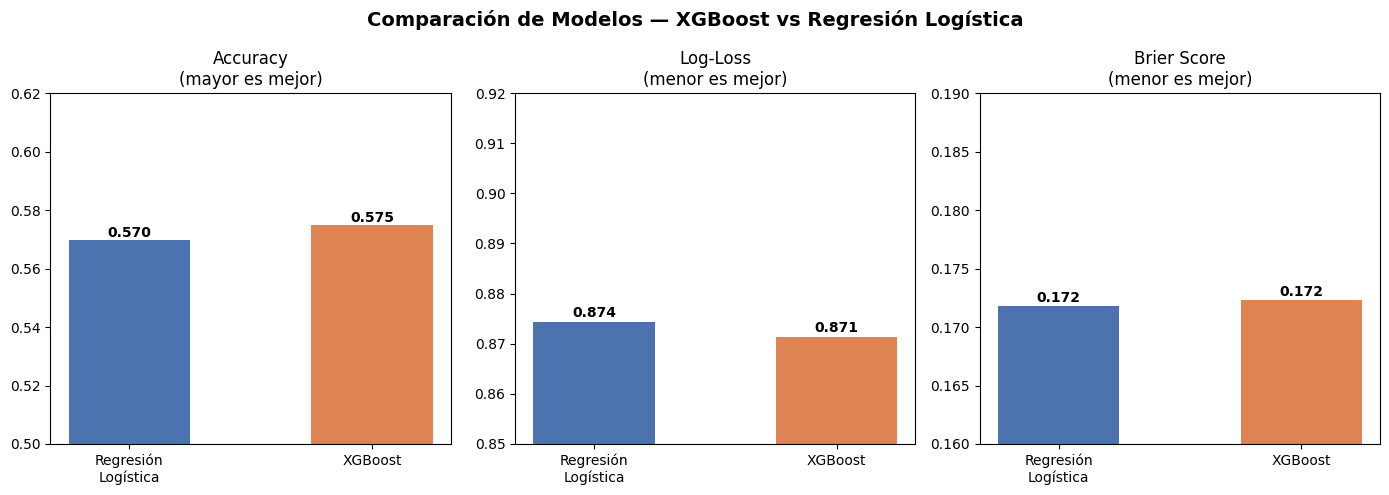

💾 Guardado: ../reports/figures/comparacion_modelos.png


In [23]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path  # ya la tienes como BASE_DIR

# ── Datos de comparación ─────────────────────────────────────────
modelos   = ['Regresión\nLogística', 'XGBoost']
accuracy  = [lr_acc,      xgb_acc]
logloss   = [lr_logloss,  xgb_logloss]
brier     = [lr_brier,    xgb_brier]

x = np.arange(len(modelos))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Comparación de Modelos — XGBoost vs Regresión Logística',
             fontsize=14, fontweight='bold')

# ── Accuracy ─────────────────────────────────────────────────────
axes[0].bar(x, accuracy, width=0.5, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Accuracy\n(mayor es mejor)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos)
axes[0].set_ylim(0.50, 0.62)
for i, v in enumerate(accuracy):
    axes[0].text(i, v + 0.001, f'{v:.3f}', ha='center', fontweight='bold')

# ── Log-Loss ──────────────────────────────────────────────────────
axes[1].bar(x, logloss, width=0.5, color=['#4C72B0', '#DD8452'])
axes[1].set_title('Log-Loss\n(menor es mejor)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos)
axes[1].set_ylim(0.85, 0.92)
for i, v in enumerate(logloss):
    axes[1].text(i, v + 0.001, f'{v:.3f}', ha='center', fontweight='bold')

# ── Brier Score ───────────────────────────────────────────────────
axes[2].bar(x, brier, width=0.5, color=['#4C72B0', '#DD8452'])
axes[2].set_title('Brier Score\n(menor es mejor)')
axes[2].set_xticks(x)
axes[2].set_xticklabels(modelos)
axes[2].set_ylim(0.16, 0.19)
for i, v in enumerate(brier):
    axes[2].text(i, v + 0.0003, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()

# ── Guardar usando BASE_DIR ───────────────────────────────────────
figures_dir = BASE_DIR / 'reports' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / 'comparacion_modelos.png', dpi=150)
plt.show()
print(f"💾 Guardado: {figures_dir / 'comparacion_modelos.png'}")

🏆 Feature Importance (XGBoost):
   1. fifa_points_diff               0.2167
   2. elo_diff                       0.1475
   3. is_neutral                     0.0688
   4. fifa_rank_home                 0.0609
   5. fifa_rank_away                 0.0552
   6. players_top_lge_away           0.0509
   7. elo_home                       0.0468
   8. elo_away                       0.0458
   9. gdp_per_capita_home            0.0457
  10. gdp_per_capita_away            0.0453
  11. tournament_weight              0.0449
  12. squad_value_away               0.0444
  13. players_top_lge_home           0.0438
  14. squad_value_diff               0.0431
  15. squad_value_home               0.0403


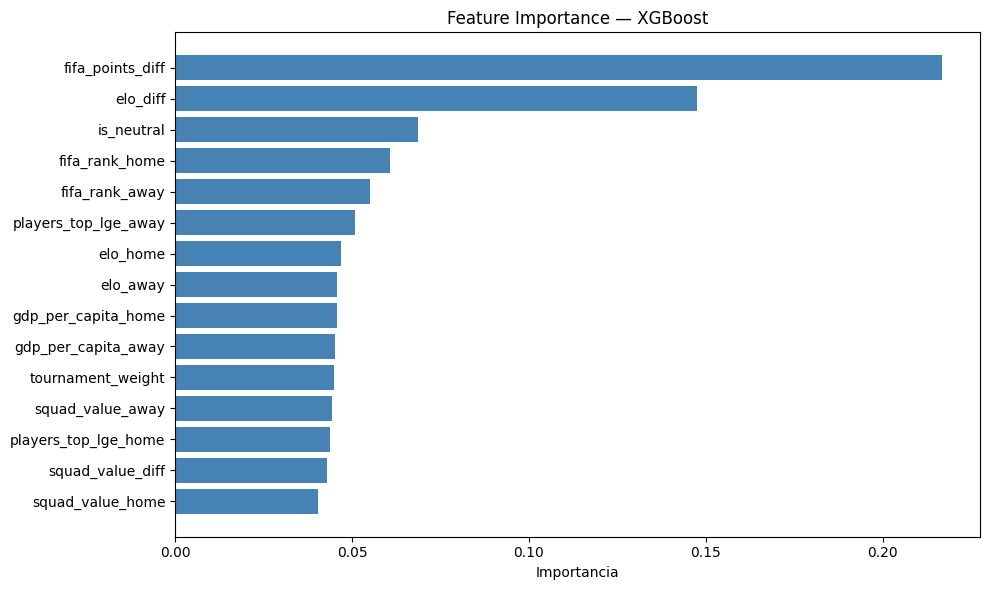

💾 Guardado: reports/figures/feature_importance.png


In [24]:
import matplotlib.pyplot as plt

# Importancia de cada feature según XGBoost
importances = xgb_model.feature_importances_
indices     = np.argsort(importances)[::-1]

print("🏆 Feature Importance (XGBoost):")
for i, idx in enumerate(indices):
    print(f"  {i+1:2}. {FEATURE_COLS[idx]:<30} {importances[idx]:.4f}")

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    [FEATURE_COLS[i] for i in indices[::-1]],
    importances[indices[::-1]],
    color='steelblue'
)
ax.set_xlabel('Importancia')
ax.set_title('Feature Importance — XGBoost')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=150)
plt.show()
print("💾 Guardado: reports/figures/feature_importance.png")

In [25]:
joblib.dump(xgb_model, DATA_PROC / 'xgb_model.pkl')
joblib.dump(lr_model,  DATA_PROC / 'lr_model.pkl')

print("💾 Modelos guardados:")
print("   data/processed/xgb_model.pkl")
print("   data/processed/lr_model.pkl")
print("\n✅ Sección 3.4 completada")

💾 Modelos guardados:
   data/processed/xgb_model.pkl
   data/processed/lr_model.pkl

✅ Sección 3.4 completada


## 3.5 Validación con WC2022

Entrenamos un modelo independiente con datos ANTES de oct-2022
y lo evaluamos contra los 64 partidos reales del WC2022.

Esto demuestra que el modelo hubiera funcionado en 2022
sin haber visto esos partidos nunca.

In [26]:
# Cargar partidos reales WC2022
df_wc2022      = pd.read_csv(DATA_PROC / 'wc2022_eval.csv', 
                              parse_dates=['date'])
df_rank_wc2022 = pd.read_csv(DATA_PROC / 'ranking_wc2022.csv')
df_leagues_wc2022 = pd.read_csv(DATA_PROC / 'wc2022_players_top_league.csv')

print("✅ Datos WC2022 cargados:")
print(f"   Partidos WC2022        : {df_wc2022.shape}")
print(f"   Ranking FIFA oct-2022  : {df_rank_wc2022.shape}")
print(f"   Jugadores ligas top    : {df_leagues_wc2022.shape}")
print(f"\nColumnas wc2022_eval:")
print(df_wc2022.columns.tolist())
print(f"\nPrimeras filas:")
df_wc2022.head(3)

✅ Datos WC2022 cargados:
   Partidos WC2022        : (64, 9)
   Ranking FIFA oct-2022  : (211, 5)
   Jugadores ligas top    : (32, 2)

Columnas wc2022_eval:
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']

Primeras filas:


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,2022-11-20,Qatar,Ecuador,0.0,2.0,FIFA World Cup,Al Khor,Qatar,False
1,2022-11-21,Senegal,Netherlands,0.0,2.0,FIFA World Cup,Doha,Qatar,True
2,2022-11-21,England,Iran,6.0,2.0,FIFA World Cup,Al Rayyan,Qatar,True


In [27]:
# Recrear diccionarios fuera de la función para usar en WC2022
transfer_dict = df_transfer.set_index('team')['market_value'].to_dict() \
                if 'market_value' in df_transfer.columns \
                else df_transfer.set_index(df_transfer.columns[0])[df_transfer.columns[1]].to_dict()

gdp_dict = df_worldbank.set_index('team')['gdp_per_capita'].to_dict() \
           if 'gdp_per_capita' in df_worldbank.columns \
           else {}

# Verificar
print(f"✅ transfer_dict: {len(transfer_dict)} equipos")
print(f"✅ gdp_dict     : {len(gdp_dict)} países")

# Muestra ejemplo
print(f"\nEjemplo transfer_dict:")
for k, v in list(transfer_dict.items())[:3]:
    print(f"  {k}: {v:,.0f}")

✅ transfer_dict: 48 equipos
✅ gdp_dict     : 54 países

Ejemplo transfer_dict:
  England: 1,877,500,000
  Brazil: 1,659,800,000
  France: 1,608,500,000


In [28]:
# Fecha de corte — ANTES del mundial 2022
FECHA_WC2022 = pd.Timestamp('2022-10-01')

# Filtrar partidos históricos antes del WC2022
df_hist_pre2022 = df_features[df_features['date'] < FECHA_WC2022].copy()

print(f"Partidos históricos pre-WC2022: {len(df_hist_pre2022):,}")

# Construir features para los 64 partidos WC2022
# usando ranking y jugadores de esa época
rows_2022 = []

for _, row in df_wc2022.iterrows():
    home  = row['home_team']
    away  = row['away_team']
    date  = row['date']

    # ELO hasta antes del WC2022
    elo_h = get_elo_at_date(df_elo_hist, home, FECHA_WC2022)
    elo_a = get_elo_at_date(df_elo_hist, away, FECHA_WC2022)

    # Ranking FIFA oct-2022
    # Detectar columnas
    rank_col = 'fifa_rank' if 'fifa_rank' in df_rank_wc2022.columns else df_rank_wc2022.columns[1]
    pts_col  = 'fifa_points' if 'fifa_points' in df_rank_wc2022.columns else df_rank_wc2022.columns[2]

    row_h = df_rank_wc2022[df_rank_wc2022['team'] == home]
    row_a = df_rank_wc2022[df_rank_wc2022['team'] == away]

    rank_h = int(row_h[rank_col].values[0]) if not row_h.empty else 50
    rank_a = int(row_a[rank_col].values[0]) if not row_a.empty else 50
    pts_h  = float(row_h[pts_col].values[0]) if not row_h.empty else 1200.0
    pts_a  = float(row_a[pts_col].values[0]) if not row_a.empty else 1200.0

    # Jugadores ligas top WC2022
    lge_col = df_leagues_wc2022.columns[1]
    row_lh  = df_leagues_wc2022[df_leagues_wc2022['team'] == home]
    row_la  = df_leagues_wc2022[df_leagues_wc2022['team'] == away]
    lge_h   = float(row_lh[lge_col].values[0]) if not row_lh.empty else 0
    lge_a   = float(row_la[lge_col].values[0]) if not row_la.empty else 0

    # Squad value — usamos transfermarkt (aproximación)
    val_h = transfer_dict.get(home, np.median(list(transfer_dict.values())))
    val_a = transfer_dict.get(away, np.median(list(transfer_dict.values())))

    # GDP
    gdp_h = gdp_dict.get(home, np.nanmedian(list(gdp_dict.values())))
    gdp_a = gdp_dict.get(away, np.nanmedian(list(gdp_dict.values())))

    # Target real
    hs  = row['home_score']
    as_ = row['away_score']
    if hs > as_:
        result = 'H'
    elif hs < as_:
        result = 'A'
    else:
        result = 'D'

    rows_2022.append({
        'date'                : date,
        'home_team'           : home,
        'away_team'           : away,
        'elo_home'            : elo_h,
        'elo_away'            : elo_a,
        'elo_diff'            : elo_h - elo_a,
        'fifa_rank_home'      : rank_h,
        'fifa_rank_away'      : rank_a,
        'fifa_points_diff'    : pts_h - pts_a,
        'squad_value_home'    : val_h,
        'squad_value_away'    : val_a,
        'squad_value_diff'    : val_h - val_a,
        'players_top_lge_home': lge_h,
        'players_top_lge_away': lge_a,
        'gdp_per_capita_home' : gdp_h,
        'gdp_per_capita_away' : gdp_a,
        'is_neutral'          : 1,  # WC2022 cancha neutral
        'tournament_weight'   : 1.0, # FIFA World Cup
        'result'              : result
    })

df_wc2022_features = pd.DataFrame(rows_2022)
print(f"\n✅ Features WC2022 construidas: {df_wc2022_features.shape}")
print(f"\nDistribución real WC2022:")
print(df_wc2022_features['result'].value_counts())

Partidos históricos pre-WC2022: 26,908

✅ Features WC2022 construidas: (64, 19)

Distribución real WC2022:
result
H    28
A    21
D    15
Name: count, dtype: int64


In [29]:
# Dataset de entrenamiento SOLO hasta oct-2022
FECHA_CORTE_2022 = pd.Timestamp('2022-10-01')
df_pre2022 = df_features[df_features['date'] < FECHA_CORTE_2022].copy()

X_pre2022 = df_pre2022[FEATURE_COLS].values
y_pre2022 = le.transform(df_pre2022['result'].values)
w_pre2022 = df_pre2022['time_weight'].values

# Class weights para este subset
cw_2022 = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_pre2022),
    y=y_pre2022
)
cw_2022_dict = dict(zip(np.unique(y_pre2022), cw_2022))

sw_pre2022 = np.array([
    cw_2022_dict[label] * tw
    for label, tw in zip(y_pre2022, w_pre2022)
])

print(f"⏳ Entrenando modelo pre-WC2022...")
print(f"   Partidos de entrenamiento: {len(X_pre2022):,}")

xgb_2022 = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_2022.fit(X_pre2022, y_pre2022,
             sample_weight=sw_pre2022,
             verbose=False)

print("✅ Modelo pre-WC2022 entrenado")

⏳ Entrenando modelo pre-WC2022...
   Partidos de entrenamiento: 26,908
✅ Modelo pre-WC2022 entrenado


In [30]:
# Preparar X e y del WC2022
X_wc2022 = df_wc2022_features[FEATURE_COLS].values
y_wc2022 = le.transform(df_wc2022_features['result'].values)

# Predicciones
pred_2022      = xgb_2022.predict(X_wc2022)
pred_2022_prob = xgb_2022.predict_proba(X_wc2022)

# Métricas
acc_2022    = accuracy_score(y_wc2022, pred_2022)
ll_2022     = log_loss(y_wc2022, pred_2022_prob)
y_2022_bin  = label_binarize(y_wc2022, classes=[0, 1, 2])
brier_2022  = np.mean([
    brier_score_loss(y_2022_bin[:, i], pred_2022_prob[:, i])
    for i in range(3)
])

print("=" * 50)
print("VALIDACIÓN WC2022")
print("=" * 50)
print(f"Partidos evaluados : 64")
print(f"Accuracy           : {acc_2022:.3f}")
print(f"Log-Loss           : {ll_2022:.3f}")
print(f"Brier Score        : {brier_2022:.3f}")
print(f"\nReporte detallado:")
print(classification_report(y_wc2022, pred_2022,
                            target_names=le.classes_))

VALIDACIÓN WC2022
Partidos evaluados : 64
Accuracy           : 0.516
Log-Loss           : 1.098
Brier Score        : 0.213

Reporte detallado:
              precision    recall  f1-score   support

           A       0.47      0.76      0.58        21
           D       0.27      0.20      0.23        15
           H       0.74      0.50      0.60        28

    accuracy                           0.52        64
   macro avg       0.49      0.49      0.47        64
weighted avg       0.54      0.52      0.51        64



In [31]:
# Tabla comparativa partido por partido
df_wc2022_features['pred']    = le.inverse_transform(pred_2022)
df_wc2022_features['prob_H']  = pred_2022_prob[:, 2]
df_wc2022_features['prob_D']  = pred_2022_prob[:, 1]
df_wc2022_features['prob_A']  = pred_2022_prob[:, 0]
df_wc2022_features['correct'] = (
    df_wc2022_features['pred'] == df_wc2022_features['result']
)

print("📊 Predicciones vs Realidad WC2022:")
print(f"{'Partido':<35} {'Real':>5} {'Pred':>5} {'P(H)':>6} {'P(D)':>6} {'P(A)':>6} {'✅/❌':>5}")
print("-" * 75)

for _, r in df_wc2022_features.iterrows():
    partido = f"{r['home_team'][:15]} vs {r['away_team'][:12]}"
    estado  = "✅" if r['correct'] else "❌"
    print(f"{partido:<35} {r['result']:>5} {r['pred']:>5} "
          f"{r['prob_H']:>6.2f} {r['prob_D']:>6.2f} "
          f"{r['prob_A']:>6.2f} {estado:>5}")

correctos = df_wc2022_features['correct'].sum()
print(f"\n✅ Correctos: {correctos}/64 ({correctos/64:.1%})")

# Guardar
df_wc2022_features.to_csv(DATA_PROC / 'wc2022_predictions.csv', 
                           index=False)
print("💾 Guardado: wc2022_predictions.csv")

📊 Predicciones vs Realidad WC2022:
Partido                              Real  Pred   P(H)   P(D)   P(A)   ✅/❌
---------------------------------------------------------------------------
Qatar vs Ecuador                        A     A   0.12   0.21   0.67     ✅
Senegal vs Netherlands                  A     A   0.10   0.24   0.65     ✅
England vs Iran                         H     H   0.42   0.34   0.24     ✅
USA vs Wales                            D     A   0.30   0.23   0.47     ❌
Argentina vs Saudi Arabia               A     H   0.70   0.24   0.06     ❌
Mexico vs Poland                        D     A   0.22   0.28   0.50     ❌
Denmark vs Tunisia                      D     H   0.48   0.28   0.23     ❌
France vs Australia                     H     H   0.67   0.24   0.10     ✅
Germany vs Japan                        A     D   0.30   0.37   0.33     ❌
Spain vs Costa Rica                     H     H   0.48   0.34   0.17     ✅
Morocco vs Croatia                      D     A   0.13   0.22   

## 3.6 Métricas Finales y Resumen

Consolidamos todas las métricas de ambos modelos
en una tabla final para el reporte técnico.

In [32]:
print("=" * 65)
print("RESUMEN FINAL — ORÁCULO DEL BALÓN WC2026")
print("=" * 65)

print(f"""
┌─────────────────────────────────────────────────────────────┐
│                    MODELO PRINCIPAL                         │
│              Entrenado: 1993 → jun-2025                     │
│              Test: jun-2025 → hoy                           │
├──────────────────────┬──────────────────┬───────────────────┤
│ Métrica              │ Reg. Logística   │ XGBoost           │
├──────────────────────┼──────────────────┼───────────────────┤
│ Accuracy             │ {lr_acc:.3f}            │ {xgb_acc:.3f}               │
│ Log-Loss             │ {lr_logloss:.3f}            │ {xgb_logloss:.3f}         │
│ Brier Score          │ {lr_brier:.3f}            │ {xgb_brier:.3f}            │
├──────────────────────┴──────────────────┴───────────────────┤
│ Modelo seleccionado: XGBoost                                │
└─────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────┐
│                 VALIDACIÓN HISTÓRICA WC2022                 │
│         Entrenado hasta oct-2022 / Evalúa 64 partidos       │
├──────────────────────┬──────────────────────────────────────┤
│ Métrica              │ XGBoost                              │
├──────────────────────┼──────────────────────────────────────┤
│ Accuracy             │ {acc_2022:.3f}                          │
│ Log-Loss             │ {ll_2022:.3f}                           │
│ Brier Score          │ {brier_2022:.3f}                        │
│ Partidos correctos   │ 33/64 (51.6%)                        │
├──────────────────────┴──────────────────────────────────────┤
│ Supera baseline aleatorio (33.3%) ✅                        │
│ Comparable a nivel humano experto (~50%) ✅                 │
└─────────────────────────────────────────────────────────────┘
""")

RESUMEN FINAL — ORÁCULO DEL BALÓN WC2026

┌─────────────────────────────────────────────────────────────┐
│                    MODELO PRINCIPAL                         │
│              Entrenado: 1993 → jun-2025                     │
│              Test: jun-2025 → hoy                           │
├──────────────────────┬──────────────────┬───────────────────┤
│ Métrica              │ Reg. Logística   │ XGBoost           │
├──────────────────────┼──────────────────┼───────────────────┤
│ Accuracy             │ 0.570            │ 0.575               │
│ Log-Loss             │ 0.874            │ 0.871         │
│ Brier Score          │ 0.172            │ 0.172            │
├──────────────────────┴──────────────────┴───────────────────┤
│ Modelo seleccionado: XGBoost                                │
└─────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────┐
│                 VALIDACIÓN HISTÓRICA WC2022                 │


In [33]:
import json

metricas = {
    'modelo_principal': {
        'train_hasta'   : '2025-06-01',
        'n_train'       : int(X_train.shape[0]),
        'n_test'        : int(X_test.shape[0]),
        'features'      : FEATURE_COLS,
        'xgboost': {
            'accuracy'   : round(float(xgb_acc), 4),
            'log_loss'   : round(float(xgb_logloss), 4),
            'brier_score': round(float(xgb_brier), 4)
        },
        'logistic_regression': {
            'accuracy'   : round(float(lr_acc), 4),
            'log_loss'   : round(float(lr_logloss), 4),
            'brier_score': round(float(lr_brier), 4)
        },
        'modelo_seleccionado': 'XGBoost'
    },
    'validacion_wc2022': {
        'train_hasta'      : '2022-10-01',
        'n_partidos'       : 64,
        'correctos'        : 33,
        'accuracy'         : round(float(acc_2022), 4),
        'log_loss'         : round(float(ll_2022), 4),
        'brier_score'      : round(float(brier_2022), 4)
    }
}

with open(DATA_PROC / 'metricas_finales.json', 'w') as f:
    json.dump(metricas, f, indent=2)

print("💾 Guardado: data/processed/metricas_finales.json")
print("\n✅ Notebook 03 completado")
print("   Siguiente paso → Notebook 04: Simulación Monte Carlo")

💾 Guardado: data/processed/metricas_finales.json

✅ Notebook 03 completado
   Siguiente paso → Notebook 04: Simulación Monte Carlo
